# Regression Tree


In [ ]:
import pandas as pd
#Load the cleaned data
df = pd.read_csv('data/antarctica_temp_data/cleaned_noaa_data.csv')

print(df.columns)
#Sort by time
df_sorted = df.sort_values(by=["date"])
df_sorted

Index(['date', 'temp_c', 'temp_zscore', 'temp_anomaly'], dtype='object')


,date,temp_c,temp_zscore,temp_anomaly
0,1979-01-01,1.0,0.794452,-0.464276
1,1979-01-02,5.8,1.495571,4.335724
2,1979-01-03,4.0,1.232652,2.535724
3,1979-01-04,-0.3,0.604566,-1.764276
4,1979-01-05,6.3,1.568604,4.835724
...,...,...,...,...
15892,2026-03-21,3.1,1.101192,4.865789
15893,2026-03-22,2.6,1.028158,4.365789
15894,2026-03-23,2.0,0.940519,3.765789
15895,2026-03-24,-0.5,0.575352,1.265789


In [4]:
df_tree_sorted = df.sort_values(by=["date"])
#add time lag for 1 day
df_tree_sorted["temp_lag1"] = df_tree_sorted['temp_c'].shift(1)
#add time lag for 7 days
df_tree_sorted["temp_lag7"] = df_tree_sorted['temp_c'].shift(7)
#add time lag for 30 days
df_tree_sorted["temp_lag30"] = df_tree_sorted['temp_c'].shift(30)
#add time lag for 1 year
df_tree_sorted["temp_lag365"] = df_tree_sorted['temp_c'].shift(365)

#Drop N/A
df_tree_dropna = df_tree_sorted.dropna()
df_tree_dropna

,date,temp_c,temp_zscore,temp_anomaly,temp_lag1,temp_lag7,temp_lag30,temp_lag365
365,1980-09-05,-9.6,-0.753853,-2.847381,-17.0,-22.4,-6.8,1.0
366,1980-09-06,-3.0,0.210186,3.752619,-9.6,-14.3,-15.0,5.8
367,1980-09-07,-3.5,0.137153,3.252619,-3.0,-2.8,-13.5,4.0
368,1980-09-08,-11.6,-1.045986,-4.847381,-3.5,-2.0,-18.3,-0.3
369,1980-09-09,-14.3,-1.440365,-7.547381,-11.6,-15.2,-17.5,6.3
...,...,...,...,...,...,...,...,...
15892,2026-03-21,3.1,1.101192,4.865789,2.2,4.7,-0.1,-5.3
15893,2026-03-22,2.6,1.028158,4.365789,3.1,1.6,1.0,-4.9
15894,2026-03-23,2.0,0.940519,3.765789,2.6,2.0,3.9,-0.2
15895,2026-03-24,-0.5,0.575352,1.265789,2.0,4.7,5.2,-3.0


In [5]:
#Define X (features) and Y(target variable)
X_tree = df_tree_dropna[["temp_lag1", "temp_lag7", "temp_lag30", "temp_lag365"]]
y_tree = df_tree_dropna["temp_c"]

In [6]:
#Train the regression tree model
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

X_tree_train, X_tree_test, y_tree_train, y_tree_test = train_test_split(
    X_tree, y_tree, test_size=0.2, shuffle=False
)

regr = DecisionTreeRegressor(max_depth=5, random_state=42)
regr.fit(X_tree_train, y_tree_train)

#change max_depth to 8
regr_1 = DecisionTreeRegressor(max_depth=8, random_state=42)
regr_1.fit(X_tree_train, y_tree_train)

#change max_depth to 3
regr_2 = DecisionTreeRegressor(max_depth=3, random_state=42)
regr_2.fit(X_tree_train, y_tree_train)


DecisionTreeRegressor(max_depth=3, random_state=42)

In [7]:
#Evaluate the model
y_tree_pred = regr.predict(X_tree_test)

y_tree_pred_1 = regr_1.predict(X_tree_test)

y_tree_pred_2 = regr_2.predict(X_tree_test)



from sklearn.metrics import mean_squared_error, r2_score

#Tuning max_depth parameter
print("Max_depth = 5")
print("Mean Squared Error:", mean_squared_error(y_tree_test, y_tree_pred))
print("R squared:", r2_score(y_tree_test, y_tree_pred))

print("Max_depth = 8")
print("Mean Squared Error:", mean_squared_error(y_tree_test, y_tree_pred_1))
print("R squared:", r2_score(y_tree_test, y_tree_pred_1))

print("Max_depth = 3")
print("Mean Squared Error:", mean_squared_error(y_tree_test, y_tree_pred_2))
print("R squared", r2_score(y_tree_test, y_tree_pred_2))

Max_depth = 5
Mean Squared Error: 12.494727508432408
R squared: 0.6866990306343723
Max_depth = 8
Mean Squared Error: 13.519715571850623
R squared: 0.6609978095680944
Max_depth = 3
Mean Squared Error: 12.981584951543121
R squared 0.6744912486906272


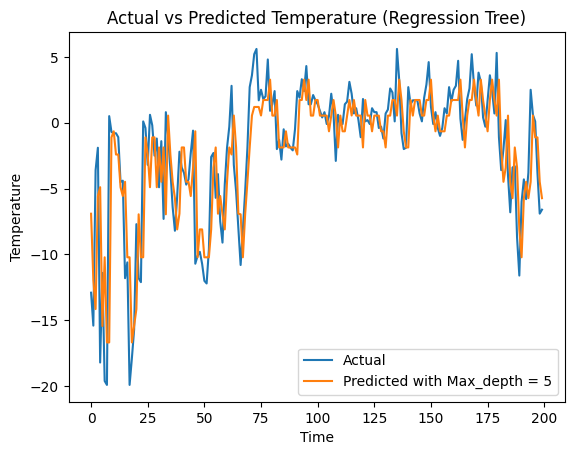

In [8]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(y_tree_test.values[:200], label="Actual")
plt.plot(y_tree_pred[:200], label="Predicted with Max_depth = 5")

plt.legend()
plt.title("Actual vs Predicted Temperature (Regression Tree)")
plt.xlabel("Time")
plt.ylabel("Temperature")

plt.show()

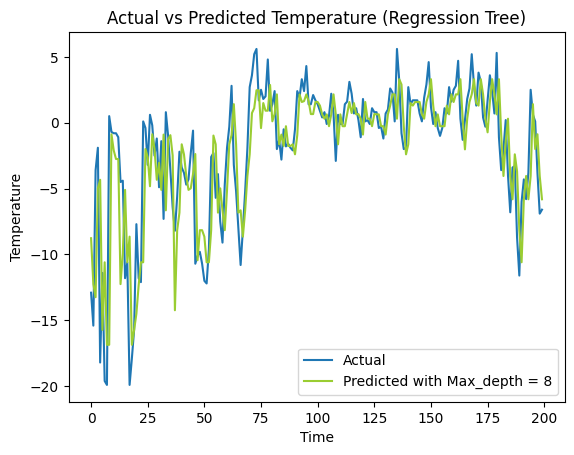

In [9]:

plt.figure()

plt.plot(y_tree_test.values[:200], label="Actual")
plt.plot(y_tree_pred_1[:200], label="Predicted with Max_depth = 8", color="yellowgreen")

plt.legend()
plt.title("Actual vs Predicted Temperature (Regression Tree)")
plt.xlabel("Time")
plt.ylabel("Temperature")

plt.show()

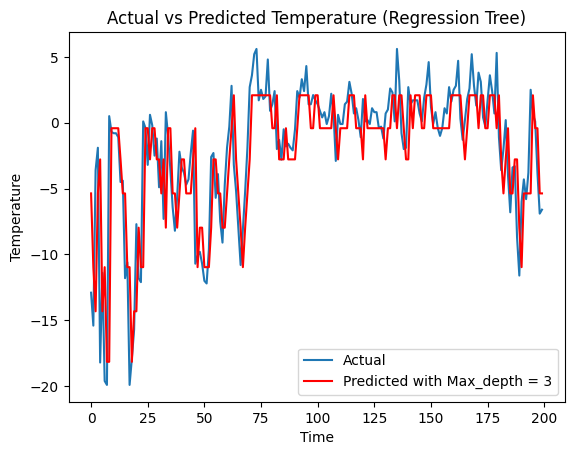

In [10]:

plt.figure()

plt.plot(y_tree_test.values[:200], label="Actual")
plt.plot(y_tree_pred_2[:200], label="Predicted with Max_depth = 3", color="red")

plt.legend()
plt.title("Actual vs Predicted Temperature (Regression Tree)")
plt.xlabel("Time")
plt.ylabel("Temperature")

plt.show()